1. Import necessary libraries and PORT-EK source code:

In [3]:
import sys
import os
import json
import pathlib
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import SeqIO

#adding portek source directory to sys path before importing
portek_path = "../portek"
sys.path.insert(0,portek_path)
import portek

pd.options.mode.copy_on_write = True
print(os.getpid())

81255


2. Declare data set specific definitions and functions:

In [4]:
# PORT-EK parameters
k = 15  # This is the kmer length.
c = 0.1 # This is the conservation thershold used in k-mer rarity filter.
m = 2  # This is the maximum number of mismatches allowed when re-examining rare k-mers.
min_RMSE = 0.1  # This is the RMSE threshold used to select enriched k-mers.
m_map = 2  # This is the maximum number of mismatches allowed when mapping k-mers to reference genome.
l_map = 1000  # This the maximum allowed offset of mapping position from average position of k-mer in samples.

# Relative path to k-mer indices.
INPUT_PATH = f"../output/bat/{k}mer_indices"

# Data set specific definitions of k-mer type, column names, reference gene and protein mapping, and colors for plots.

FREQ_COLS = ["bat_freq", "hum_freq"]
AVG_COLS = [
    "bat_avg",
    "hum_avg",
]
VOLCANO_CMAP = {
    "not significant": ("#DDDDDD", 0.5),
    "bat over-represented": ("#870f7e", 1),
    "human over-represented": ("#005ff5", 1),
}
GENE_ORDER_LIST = [
    "orf1ab",
    "S",
    "orf3a",
    "E",
    "M",
    "orf6",
    "orf7a",
    "orf7b",
    "orf8",
    "N",
    "orf10",
    "intergenic",
]
PROTEIN_ORDER_LIST = [
    "nsp1",
    "nsp2",
    "nsp3",
    "nsp4",
    "nsp5",
    "nsp6",
    "nsp7",
    "nsp8",
    "nsp9",
    "nsp10",
    "nsp12",
    "nsp13",
    "nsp14",
    "nsp15",
    "nsp16",
    "S",
    "orf3a",
    "E",
    "M",
    "orf6",
    "orf7a",
    "orf7b",
    "orf8",
    "N",
    "orf10",
    "non-coding",
]


def assign_kmer_type(row):
    if row["bat_err"] > 0 and row["p-value"] < 0.01:
        return "bat over-represented"
    elif row["bat_err"] < 0 and row["p-value"] < 0.01:
        return "human over-represented"
    else:
        return "not significant"


def assign_gene(pos):
    if pos in range(266, 21555 + 1):
        gene = "orf1ab"
    elif pos in range(21563, 25384 + 1):
        gene = "S"
    elif pos in range(25393, 26220 + 1):
        gene = "orf3a"
    elif pos in range(26245, 26472 + 1):
        gene = "E"
    elif pos in range(26523, 27191 + 1):
        gene = "M"
    elif pos in range(27202, 27387 + 1):
        gene = "orf6"
    elif pos in range(27394, 27759 + 1):
        gene = "orf7a"
    elif pos in range(27756, 27887 + 1):
        gene = "orf7b"
    elif pos in range(27894, 28259 + 1):
        gene = "orf8"
    elif pos in range(28274, 29533 + 1):
        gene = "N"
    elif pos in range(29558, 29674 + 1):
        gene = "orf10"
    else:
        gene = "intergenic"
    return gene


def assign_protein(pos):
    if pos in range(266, 805 + 1):
        protein = "nsp1"
    elif pos in range(806, 2719 + 1):
        protein = "nsp2"
    elif pos in range(2720, 8554 + 1):
        protein = "nsp3"
    elif pos in range(8555, 10054 + 1):
        protein = "nsp4"
    elif pos in range(10055, 10972 + 1):
        protein = "nsp5"
    elif pos in range(10973, 11842 + 1):
        protein = "nsp6"
    elif pos in range(11843, 12091 + 1):
        protein = "nsp7"
    elif pos in range(12092, 12685 + 1):
        protein = "nsp8"
    elif pos in range(12686, 13024 + 1):
        protein = "nsp9"
    elif pos in range(13025, 13441 + 1):
        protein = "nsp10"
    elif pos in range(13442, 16236 + 1):
        protein = "nsp12"
    elif pos in range(16237, 18039 + 1):
        protein = "nsp13"
    elif pos in range(18040, 19620 + 1):
        protein = "nsp14"
    elif pos in range(19621, 20658 + 1):
        protein = "nsp15"
    elif pos in range(20659, 21555 + 1):
        protein = "nsp16"
    elif pos in range(21563, 25384 + 1):
        protein = "S"
    elif pos in range(25393, 26220 + 1):
        protein = "orf3a"
    elif pos in range(26245, 26472 + 1):
        protein = "E"
    elif pos in range(26523, 27191 + 1):
        protein = "M"
    elif pos in range(27202, 27387 + 1):
        protein = "orf6"
    elif pos in range(27394, 27759 + 1):
        protein = "orf7a"
    elif pos in range(27756, 27887 + 1):
        protein = "orf7b"
    elif pos in range(27894, 28259 + 1):
        protein = "orf8"
    elif pos in range(28274, 29533 + 1):
        protein = "N"
    elif pos in range(29558, 29674 + 1):
        protein = "orf10"
    else:
        protein = "non-coding"
    return protein


def bootstrap_sample_group(sample_idx: list, k_samples:int, n_times:int):
    rng = np.random.default_rng()
    boostraps = []
    for _ in range(n_times):
        sample = rng.choice(sample_idx, k_samples, replace=False).tolist()
        boostraps.append(sample)
    return boostraps

3. Construct k-mer bootstrapped count matrices and apply rarity filter

In [5]:
# Choose a random subset of samples for bootstrapping.
print("\nBootstrapping human samples.")
bat_sample_idx = [filename.stem for filename in pathlib.Path(INPUT_PATH).glob("bat*")]
hum_sample_idx = [filename.stem for filename in pathlib.Path(INPUT_PATH).glob("hum*")]
print(len(bat_sample_idx), len(hum_sample_idx))

n_bootstraps = 20
hum_bootstrapped_idx = bootstrap_sample_group(hum_sample_idx, len(bat_sample_idx), n_bootstraps)
print(f"\nBootstrapped {n_bootstraps} sets of human samples.")

# Perform bootstrapping loop
bootstrapped_kmer_matrices = []
for i in range(n_bootstraps):
    print(f"\nBootstrapping iteration {i+1} of {n_bootstraps}.")

    # First read all sample labels and k-mer sequences and construct an empty matrix. It requires significantly less memory than updating the table one-by-one.
    kmer_set = set()
    sample_list = bat_sample_idx+hum_bootstrapped_idx[i]
    in_paths = [pathlib.Path(f"{INPUT_PATH}/{sample}.json") for sample in sample_list]
    
    for filename in in_paths:
        with open(filename, mode="r") as in_file:
            temp_dict = json.load(in_file)
        kmer_set.update(temp_dict.keys())

    bs_kmer_matrix = pd.DataFrame(
        0, index=list(kmer_set), columns=sample_list, dtype="uint8"
    )
    print(f"\nImported {len(kmer_set)} kmers and {len(sample_list)} samples.")

    # Fill the matrix with k-mer counts.
    counter = 1
    tot_files = len(sample_list)

    for filename in in_paths:
        print(
            f"Loading {filename.stem}. {counter-1} of {tot_files} indices done.",
            end="\r",
            flush=True,
        )
        with open(filename, mode="r") as in_file:
            temp_dict = json.load(in_file)
        count_dict = {f"{filename.stem}": [len(pos) for pos in temp_dict.values()]}
        temp_df = pd.DataFrame(count_dict, index=temp_dict.keys(), dtype="uint8")
        if temp_df.columns[0] not in bs_kmer_matrix.columns:
            print(f"Sample {filename.stem} not found in matrix columns.")
            continue
        if any(~temp_df.index.isin(bs_kmer_matrix.index)):
            print(f"K-mers not found in matrix index.")
            continue
        bs_kmer_matrix.update(temp_df)

        counter += 1

    # Construct a temporary binary count matrix, i.e. one that shows if a k-mer is present in sequence, without regards to actual count.
    # Calculate k-mer frequencies and average counts in host groups.
    bin_kmer_matrix = bs_kmer_matrix > 0
    bs_kmer_matrix["bat_freq"] = bin_kmer_matrix.loc[:, bat_sample_idx].mean(axis=1)
    bs_kmer_matrix["hum_freq"] = bin_kmer_matrix.loc[:, hum_bootstrapped_idx[i]].mean(
        axis=1
    )
    bs_kmer_matrix["bat_avg"] = bs_kmer_matrix.loc[:, bat_sample_idx].mean(axis=1)
    bs_kmer_matrix["hum_avg"] = bs_kmer_matrix.loc[:, hum_bootstrapped_idx[i]].mean(
        axis=1
    )
    del bin_kmer_matrix

    # Remove polyA, as it's presence and count is mostly dependant on sequencing quality not viral variant.
    if "AAAAAAAAAAAAAAA" in bs_kmer_matrix.index:
        bs_kmer_matrix = bs_kmer_matrix.drop("AAAAAAAAAAAAAAA")

    # Apply rarity filter.
    common_kmer_matrix = portek.filter_kmers(
        bs_kmer_matrix, freq_cols=FREQ_COLS, cons_thr=c
    )

    print(
        f"\n{len(common_kmer_matrix)} common k-mers remaining after filtering at a threshold of {c}."
    )
    bootstrapped_kmer_matrices.append(common_kmer_matrix)


Bootstrapping human samples.
263 2081

Bootstrapped 20 sets of human samples.

Bootstrapping iteration 1 of 20.

Imported 1421506 kmers and 526 samples.
Loading hum_EPI_ISL_629083. 525 of 526 indices done...
72472 common k-mers remaining after filtering at a threshold of 0.1.

Bootstrapping iteration 2 of 20.

Imported 1422186 kmers and 526 samples.
Loading hum_EPI_ISL_479798. 525 of 526 indices done...
72469 common k-mers remaining after filtering at a threshold of 0.1.

Bootstrapping iteration 3 of 20.

Imported 1421762 kmers and 526 samples.
Loading hum_EPI_ISL_1064080. 525 of 526 indices done..
72469 common k-mers remaining after filtering at a threshold of 0.1.

Bootstrapping iteration 4 of 20.

Imported 1422233 kmers and 526 samples.
Loading hum_EPI_ISL_18072209. 525 of 526 indices done.
72469 common k-mers remaining after filtering at a threshold of 0.1.

Bootstrapping iteration 5 of 20.

Imported 1422147 kmers and 526 samples.
Loading hum_EPI_ISL_413611. 525 of 526 indices don

4. Calculate common k-mer statistics and identify host over-represented k-mers.

In [6]:
for i, common_kmer_matrix in enumerate(bootstrapped_kmer_matrices):
    bs_sample_list = bat_sample_idx+hum_bootstrapped_idx[i]
    # Calculate mean k-mer count change, RMSE and test statistical significance.
    common_kmer_matrix["bat_err"] = (
        common_kmer_matrix["bat_avg"] - common_kmer_matrix["hum_avg"]
    )

    common_kmer_matrix["bat_RMSE"] = np.sqrt(
        (
            (common_kmer_matrix["bat_err"]) ** 2
        )
    )
    common_kmer_matrix["seq"] = common_kmer_matrix.index
    common_kmer_matrix["p-value"] = common_kmer_matrix["seq"].apply(
        portek.calc_kmer_pvalue,
        args=(bat_sample_idx, hum_bootstrapped_idx[i], common_kmer_matrix),
    )
    common_kmer_matrix = common_kmer_matrix.sort_values("bat_RMSE", ascending=False)
    common_kmer_matrix = common_kmer_matrix.drop("seq", axis=1)
    common_kmer_matrix["-log10_p-value"] = -np.log10(
        common_kmer_matrix["p-value"]
    )

    # Identify host-overrepresented k-mers, according to the statistics calculated above.
    common_kmer_matrix["group"] = common_kmer_matrix.apply(assign_kmer_type, axis=1)

    # Drop counts, for export and analysis.
    common_kmer_matrix = common_kmer_matrix.drop(bs_sample_list, axis=1)
    bootstrapped_kmer_matrices[i] = common_kmer_matrix

42485 bat enriched k-mers and 29960 human enriched k-mers found.
42483 bat enriched k-mers and 29954 human enriched k-mers found.
42481 bat enriched k-mers and 29962 human enriched k-mers found.
42482 bat enriched k-mers and 29965 human enriched k-mers found.
42488 bat enriched k-mers and 29960 human enriched k-mers found.
42488 bat enriched k-mers and 29962 human enriched k-mers found.
42490 bat enriched k-mers and 29971 human enriched k-mers found.
42487 bat enriched k-mers and 29960 human enriched k-mers found.
42484 bat enriched k-mers and 29968 human enriched k-mers found.
42488 bat enriched k-mers and 29957 human enriched k-mers found.
42486 bat enriched k-mers and 29951 human enriched k-mers found.
42484 bat enriched k-mers and 29960 human enriched k-mers found.
42488 bat enriched k-mers and 29961 human enriched k-mers found.
42490 bat enriched k-mers and 29957 human enriched k-mers found.
42485 bat enriched k-mers and 29968 human enriched k-mers found.
42489 bat enriched k-mers

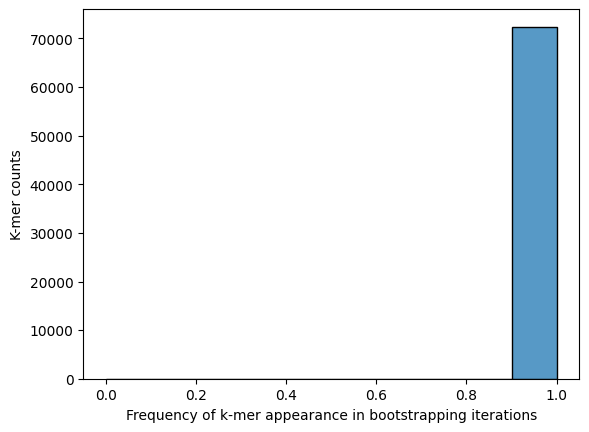

In [10]:
complete_enriched_kmer_stat_matrix = pd.read_csv(f"../output/bat/enriched_{k}mer_stat_matrix.csv", index_col=0)
complete_enriched_kmer_stat_matrix["bootstrapped_count"] = 0
for common_kmer_matrix in bootstrapped_kmer_matrices:
    bat_enriched = common_kmer_matrix[(common_kmer_matrix["group"] == "bat over-represented") & (common_kmer_matrix["bat_RMSE"] > min_RMSE)]
    human_enriched = common_kmer_matrix[(common_kmer_matrix["group"] == "human over-represented") & (common_kmer_matrix["bat_RMSE"] > min_RMSE)]
    enriched_kmer_matrix = pd.concat([bat_enriched, human_enriched])
    print(
        f"{len(bat_enriched)} bat enriched k-mers and {len(human_enriched)} human enriched k-mers found."
    )
    enriched_present_in_bootstrap = enriched_kmer_matrix.loc[enriched_kmer_matrix.index.isin(complete_enriched_kmer_stat_matrix.index)].index
    complete_enriched_kmer_stat_matrix.loc[enriched_present_in_bootstrap, "bootstrapped_count"] += 1

complete_enriched_kmer_stat_matrix["bootstrapped_freq"] = complete_enriched_kmer_stat_matrix["bootstrapped_count"]/n_bootstraps
print(len(complete_enriched_kmer_stat_matrix[complete_enriched_kmer_stat_matrix["bootstrapped_freq"] == 1])/len(complete_enriched_kmer_stat_matrix))
fig, ax = plt.subplots()
sns.histplot(complete_enriched_kmer_stat_matrix["bootstrapped_freq"], bins=10)
ax.set_xlabel("Frequency of k-mer appearance in bootstrapping iterations")
ax.set_ylabel("K-mer counts")
plt.savefig(f"../output/bat/bootstrapped_enriched_{k}mer_freq.png", dpi=600, format="png", bbox_inches="tight")
plt.savefig(f"../output/bat/bootstrapped_enriched_{k}mer_freq.svg", dpi=600, format="svg", bbox_inches="tight")